
# Notebook 40 (Claude) — Re-measurement, then One Bounded Run

The Cursor sprint persisted all 68 cortical rate traces. That makes every published number
re-derivable at zero simulation cost — and re-deriving them *is* the reproduction test.
Phase 1 is therefore the licence for everything after it: if the traces do not reproduce
the published numbers, the run stops at `INTEGRITY_FAIL` rather than reinterpreting them.

| | |
|---|---|
| 0 | locks + admissibility handoff |
| 1 | **reproduction** from persisted traces |
| 2 | direction with uncertainty — sign test, bootstrap CI, and the V3 comparison |
| 3 | the non-discriminative family, reported as a capability finding |
| 4 | variance decomposition — the only simulations |
| 5 | split status fields |
| 6 | handoff to `claude_41` |


In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd

SRC = Path.cwd().resolve().parents[0] / "src"
if not SRC.is_dir():
    SRC = Path.cwd().resolve().parents[1] / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from sleep_sbi import figure10_closure_claude_common as common
from sleep_sbi.figure10_protocol import PROJECT_ROOT

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def show(payload, keys=None):
    """Print a JSON-ish payload compactly, optionally restricted to some keys."""
    if keys is not None:
        payload = {k: payload[k] for k in keys if k in payload}
    print(json.dumps(payload, indent=2, ensure_ascii=False, default=str)[:4000])


print("python  :", sys.version.split()[0])
print("env     :", Path(sys.executable).parent.name)
print("src     :", SRC)


python  : 3.10.20
env     : neurolib
src     : D:\Year3_Mao_Projects\sleep_loop\S4_sbi\src


In [2]:

from sleep_sbi import figure10_notebook40_claude as nb40

paths = common.claude_dirs(40)
common.assert_immutables()
handoff39 = nb40.load_handoff39()
show(handoff39, ["claude40_handoff_status", "admissible_families", "excluded_families",
                 "exclusion_reasons", "rate_precision_verdict", "budget_plan"])


{
  "claude40_handoff_status": "CONTINUE",
  "admissible_families": [
    "so_waveform"
  ],
  "excluded_families": [
    "spindle_density"
  ],
  "exclusion_reasons": {
    "spindle_density": "NON_DISCRIMINATIVE_EXCLUDED"
  },
  "rate_precision_verdict": "UNDERPOWERED_AT_FROZEN_BUDGET",
  "budget_plan": {
    "spindle_candidate_runs_dropped": 32,
    "spindle_simulated_seconds_freed": 3840.0,
    "reallocated_to": "so_waveform variance decomposition (R=2)",
    "note": "Repeat 0 of each candidate is the Cursor sprint's persisted trace, reused at zero cost, so only repeats >= 1 are simulated."
  }
}



## Phase 1 — Reproduction

Same validator functions, same real-template anchor mode, same sampling rate as the Cursor
run. A disagreement here would be a disagreement about the *trace*, not about the metric.


In [3]:

engine = nb40.MetricEngine()
print("real spindle density: %.4f /min" % engine.dens_real)
print("real anchor mode    :", engine.real_anchor_mode)
print("simulation fs       : %.1f Hz" % engine.fs)


D:\Year3_Mao_Projects\sleep_loop\models\s4_personalize_fig7_v7.py:138: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF
D:\Year3_Mao_Projects\sleep_loop\valid_scripts\validate_so_waveform_heldout.py:125: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(str(row["psg_path"]), preload=True, verbose=False) # 读取psg_path路径下的edf文件，存储在raw变量中
D:\Year3_Mao_Projects\sleep_loop\valid_scripts\validate_so_waveform_heldout.py:125: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(str(row["psg_path"]), preload=True, verbose=False) # 读取psg_path路径下的edf文件，存储在raw变量中
D:\Year3_Mao

D:\Year3_Mao_Projects\sleep_loop\valid_scripts\validate_spindle_density_heldout.py:107: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(str(row["psg_path"]), preload=True, verbose=False)
D:\Year3_Mao_Projects\sleep_loop\valid_scripts\validate_spindle_density_heldout.py:107: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(str(row["psg_path"]), preload=True, verbose=False)
D:\Year3_Mao_Projects\sleep_loop\valid_scripts\validate_spindle_density_heldout.py:107: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(str(row["psg_path"]), preload=True, verbose=False)


real spindle density: 2.9577 /min
real anchor mode    : peak
simulation fs       : 1000.0 Hz


In [4]:

reproduction = nb40.phase1_reproduction(paths, engine)
show(reproduction, ["n_statistics", "n_agree", "n_disagree", "max_abs_delta", "status"])
assert reproduction["status"] == "REPRODUCED", reproduction["disagreements"]

agreement = pd.read_csv(paths["csv"] / "reproduction_agreement.csv")
display(agreement.groupby(["kind", "statistic"])["abs_delta"].max().to_frame("max_abs_delta"))


{
  "n_statistics": 136,
  "n_agree": 136,
  "n_disagree": 0,
  "max_abs_delta": 1.1102230246251565e-16,
  "status": "REPRODUCED"
}


max_abs_delta
kind      statistic                
baseline  abs_err      0.000000e+00
          corr         0.000000e+00
          density      0.000000e+00
          rmse         0.000000e+00
candidate so_corr      1.110223e-16
          so_rmse      5.551115e-17
          sp_abs_err   0.000000e+00
          sp_density   0.000000e+00


## Phase 2 — Direction, with an interval attached

The frozen rule compared point medians and stopped. Here each metric gets a two-sided sign
test against the baseline and a percentile-bootstrap CI of the candidate median, and the
label may be `INDISTINGUISHABLE` — which the frozen vocabulary had no word for, having
used `MIXED` both for *the metrics disagree* and for *we could not tell*.

The V3 column is the baseline the Cursor sprint simulated under an identical protocol and
then never read. It never enters the label — the protocol defines FAVORABLE relative to V7 —
but it is the stronger baseline on this family and it belongs in the ledger.


In [5]:

direction = nb40.phase2_direction(paths, handoff39["admissible_families"])
table = pd.read_csv(paths["csv"] / "direction_with_uncertainty.csv")
display(table)


,track,baseline,metric,reference,median,ci_low,ci_high,reference_inside_ci,n_better,n,sign_p,significant
0,7d,v7,so_corr,0.927506,0.894187,0.856843,0.923916,False,4,16,0.076813,False
1,7d,v7,so_rmse,0.380378,0.459089,0.389706,0.545584,False,4,16,0.076813,False
2,7d,v3,so_corr,0.952130,0.894187,0.854181,0.923916,False,2,16,0.004181,True
3,7d,v3,so_rmse,0.309474,0.459089,0.389706,0.534596,False,2,16,0.004181,True
4,8d,v7,so_corr,0.927506,0.907250,0.794467,0.964498,True,8,16,1.000000,False
5,8d,v7,so_rmse,0.380378,0.418485,0.266189,0.640685,True,8,16,1.000000,False
6,8d,v3,so_corr,0.952130,0.907250,0.794467,0.964498,True,6,16,0.454498,False
7,8d,v3,so_rmse,0.309474,0.418485,0.266189,0.640685,True,6,16,0.454498,False


In [6]:

for track in ("7d", "8d"):
    entry = direction["tracks"][track]
    family = entry["families"]["so_waveform"]
    print(f"── {track} ({entry['e2_ref']}) " + "─" * 60)
    print("  Claude label vs V7 :", family["vs_v7"]["label"])
    print("  Claude label vs V3 :", family["vs_v3"]["label"])
    print("  Cursor label       :", entry["cursor_family_direction"],
          "  (track:", entry["cursor_direction"] + ")")
    corr = family["vs_v7"]["metrics"]["so_corr"]
    print("  corr: %d/%d better, sign p=%.4f, median %.4f, CI [%.4f, %.4f], V7=%.4f inside CI: %s"
          % (corr["n_better"], corr["n"], corr["sign_p"], corr["median"],
             corr["ci_low"], corr["ci_high"], corr["reference"], corr["reference_inside_ci"]))


── 7d (member_4) ────────────────────────────────────────────────────────────
  Claude label vs V7 : INDISTINGUISHABLE
  Claude label vs V3 : UNFAVORABLE
  Cursor label       : UNFAVORABLE   (track: MIXED)
  corr: 4/16 better, sign p=0.0768, median 0.8942, CI [0.8568, 0.9239], V7=0.9275 inside CI: False
── 8d (member_3) ────────────────────────────────────────────────────────────
  Claude label vs V7 : INDISTINGUISHABLE
  Claude label vs V3 : INDISTINGUISHABLE
  Cursor label       : UNFAVORABLE   (track: MIXED)
  corr: 8/16 better, sign p=1.0000, median 0.9073, CI [0.7945, 0.9645], V7=0.9275 inside CI: True



## Phase 3 — The excluded family, reported honestly

Excluding the family from direction labelling does not mean discarding what it measured.
The result is the most concrete physiological statement in the whole audit — it just is not
a comparison between arms.


In [7]:

nondiscriminative = nb40.phase3_nondiscriminative(paths, handoff39["excluded_families"])
show(nondiscriminative, ["status", "contributes_direction_label", "tag", "n_arms",
                         "n_arms_at_zero", "all_arms_identical", "density_real_per_min",
                         "cursor_label_for_this_family"])
print()
print(nondiscriminative["capability_finding"])
print()
print(nondiscriminative["why_not_a_direction"])


{
  "status": "NON_DISCRIMINATIVE_EXCLUDED",
  "contributes_direction_label": false,
  "tag": "NOT_A_DIRECTION_LABEL",
  "n_arms": 34,
  "n_arms_at_zero": 34,
  "all_arms_identical": true,
  "density_real_per_min": 2.9577464788732395,
  "cursor_label_for_this_family": "FAVORABLE"
}

All 34 simulated arms -- 32 posterior candidates across both tracks plus the V3 and V7 point estimates -- produced exactly zero detector-visible sigma events under the frozen protocol, against a real N3 density of 2.96/min. The historical validator records the same zero for V1-taskfile, V3 and V7, with only V1-canonical ever reaching 1.04/min. This is a statement about what the thalamo-cortical configuration can generate, not a comparison between arms.

A statistic with no variance across arms cannot order them. The frozen rule read the resulting tie as FAVORABLE because it compares errors with '<=' and both errors are the maximum attainable value.


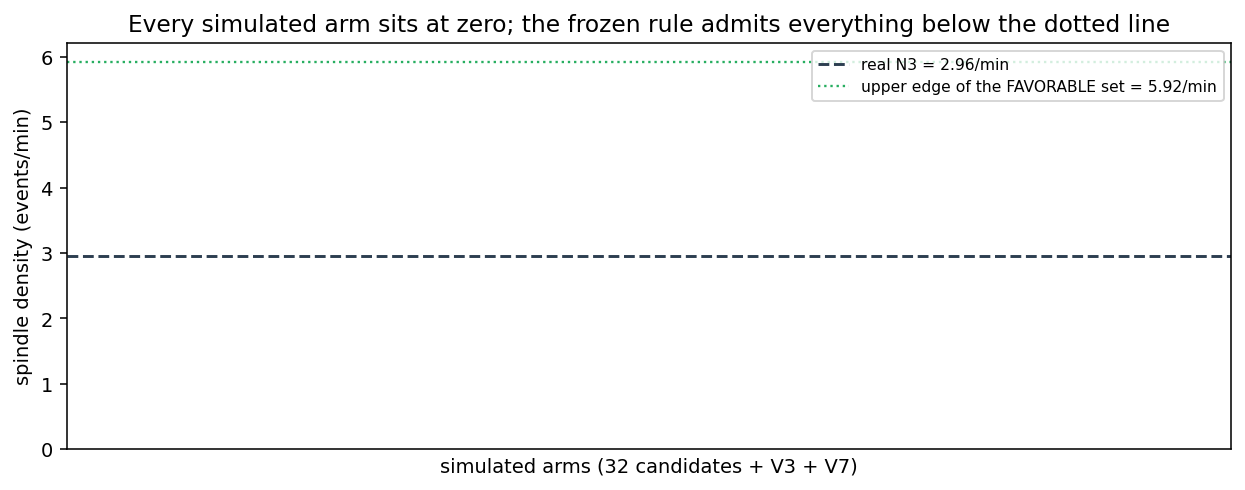

In [8]:

from IPython.display import Image, display as _display
_display(Image(filename=str(PROJECT_ROOT / nondiscriminative["figure"])))



## Phase 4 — Variance decomposition (the only simulations)

`R = 1` makes the observed candidate spread uninterpretable: it mixes the parameter draw
with the noise seed, which is why the frozen protocol correctly forbids seed-stability
claims. Repeat 0 of each candidate is the Cursor sprint's persisted trace, reused at zero
cost, so only repeats ≥ 1 are simulated — 16 new 60 s runs instead of the 32 the plan
budgeted.


In [9]:

variance = nb40.phase4_variance_decomposition(paths, engine)
show(variance, ["runs_charged", "simulated_seconds_charged", "reused_cursor_traces",
                "simulated_this_session", "reused_claude_cache",
                "simulated_seconds_ceiling", "elapsed_s"])

for track, entry in variance["per_track"].items():
    stats = entry["metrics"]["so_corr"]
    print(f"{track}: seed sd = {stats['seed_sd']:.4f}, theta sd = {stats['theta_sd']:.4f}, "
          f"share_theta = {stats['share_theta']:.3f} -> dispersion readable: "
          f"{entry['dispersion_readable']}")
print()
print(variance["interpretation"])


{
  "runs_charged": 16,
  "simulated_seconds_charged": 960.0,
  "reused_cursor_traces": 16,
  "simulated_this_session": 0,
  "reused_claude_cache": 16,
  "simulated_seconds_ceiling": 1920.0,
  "elapsed_s": 0.23749399185180664
}
7d: seed sd = 0.0240, theta sd = 0.0894, share_theta = 0.933 -> dispersion readable: True
8d: seed sd = 0.0437, theta sd = 0.0525, share_theta = 0.591 -> dispersion readable: True

share_theta is the fraction of the observed candidate spread attributable to the parameter draw rather than the noise seed. Above 0.5 the candidate-to-candidate dispersion may be read as a posterior property; below it the spread is mostly simulator noise and must not be.


In [10]:

runs = pd.read_csv(paths["csv"] / "variance_decomposition_runs.csv")
display(runs.pivot_table(index=["track", "candidate_id"], columns="repeat",
                         values="so_corr").round(4))


repeat                   0       1
track candidate_id                
7d    cand_7d_0000  0.8736  0.8515
      cand_7d_0001  0.9039  0.9406
      cand_7d_0002  0.8758  0.9279
      cand_7d_0003  0.9057  0.9313
      cand_7d_0004  0.6548  0.6614
      cand_7d_0005  0.8847  0.9276
      cand_7d_0006  0.7852  0.8294
      cand_7d_0007  0.9239  0.9108
8d    cand_8d_0000  0.7945  0.9227
      cand_8d_0001  0.7690  0.8647
      cand_8d_0002  0.9492  0.9459
      cand_8d_0003  0.9776  0.9716
      cand_8d_0004  0.9719  0.9046
      cand_8d_0005  0.9739  0.9705
      cand_8d_0006  0.9515  0.9688
      cand_8d_0007  0.9886  0.9816


## Phase 5 — Split status fields

Field names match the frozen protocol so the Notebook 41 mapping is a drop-in, with two
additions: `direction_evidence_strength` and `deciding_families`.


In [11]:

summary = nb40.phase5_status(paths, reproduction=reproduction, direction=direction,
                             nondiscriminative=nondiscriminative, variance=variance,
                             handoff39=handoff39)
show(summary, ["predictive_qualification_status", "descriptive_evidence_availability",
               "descriptive_evidence_direction", "sensitivity_concordance",
               "predictive_claim_ceiling", "reproduction", "budget",
               "claude41_handoff_status"])


{
  "predictive_qualification_status": "PREDICTIVE_UNQUALIFIED",
  "descriptive_evidence_availability": "AVAILABLE",
  "descriptive_evidence_direction": "INDISTINGUISHABLE",
  "sensitivity_concordance": "CONCORDANT",
  "predictive_claim_ceiling": "proxy_conditioned_descriptive_physiology_only",
  "reproduction": {
    "status": "REPRODUCED",
    "n_agree": 136,
    "n_statistics": 136
  },
  "budget": {
    "new_simulations": 16,
    "simulated_seconds": 960.0,
    "simulated_this_session": 0,
    "simulated_seconds_this_session": 0.0,
    "reused_cursor_traces": 16,
    "ceiling_seconds": 1920.0,
    "cursor_simulated_seconds": 6120.0,
    "cursor_runs": 68
  },
  "claude41_handoff_status": "CONTINUE"
}


In [12]:

for key in ("seven_d", "eight_d"):
    entry = summary[key]
    print(f"── {entry['track']} " + "─" * 70)
    show(entry, ["descriptive_evidence_direction", "family_directions", "vs_v3_label",
                 "deciding_families", "excluded_families", "dispersion_readable",
                 "cursor_direction"])


── 7d ──────────────────────────────────────────────────────────────────────
{
  "descriptive_evidence_direction": "INDISTINGUISHABLE",
  "family_directions": {
    "so_waveform": "INDISTINGUISHABLE"
  },
  "vs_v3_label": "UNFAVORABLE",
  "deciding_families": [
    "so_waveform"
  ],
  "excluded_families": [
    "spindle_density"
  ],
  "dispersion_readable": true,
  "cursor_direction": "MIXED"
}
── 8d ──────────────────────────────────────────────────────────────────────
{
  "descriptive_evidence_direction": "INDISTINGUISHABLE",
  "family_directions": {
    "so_waveform": "INDISTINGUISHABLE"
  },
  "vs_v3_label": "INDISTINGUISHABLE",
  "deciding_families": [
    "so_waveform"
  ],
  "excluded_families": [
    "spindle_density"
  ],
  "dispersion_readable": true,
  "cursor_direction": "MIXED"
}


In [13]:

b = summary["budget"]
print("Claude : %d runs / %.0f s simulated" % (b["new_simulations"], b["simulated_seconds"]))
print("Cursor : %d runs / %.0f s simulated" % (b["cursor_runs"], b["cursor_simulated_seconds"]))
assert b["simulated_seconds"] <= b["ceiling_seconds"]
print("\nNotebook 40 (Claude) complete.")


Claude : 16 runs / 960 s simulated
Cursor : 68 runs / 6120 s simulated

Notebook 40 (Claude) complete.
